
# **BA472 Group Project: Restaurant**
#### B472 A1 Team 3: Soomin Baek, Olivia Chou, Kristen Fan, Kiki Lau, Sammi Yang

# **Research Questions**

1.   Dine: How does working from home or not influence one’s decision to dine in or take out?
2.   Dine: How does one’s annual income influence one’s decision to dine in or take out?
3. Rewards: How does accepting loyalty program influence one's amount spent?
4. Rewards: How does shops online or not influence one’s amount spent?

# **Import Packages & Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.stats.proportion as prop
import statsmodels.api as sm

##DineInTakeOut

In [ ]:
dine = pd.read_excel('/content/drive/My Drive/BA472 Team/Group3_Restaurant2023.xlsx', sheet_name = 'DineInTakeOut')
dine.columns = dine.iloc[0]
dine = dine.drop(0).reset_index(drop=True)

In [ ]:
dine.describe()

,Date of Survey,Age,Retired,Preference,CustomerMaritalStatus,CustomerGender,WorkFromHome,ShopsOnline,Annual Income
count,459,459,459,458,459,457,459,458,457
unique,260,63,2,3,4,5,2,2,120
top,2018-03-06 00:00:00,20,0,Take-out,Single,Prefer not to answer,Yes,Yes,106
freq,5,18,336,232,123,103,252,237,9


In [ ]:
dine.head()

,Date of Survey,Age,Retired,Preference,CustomerMaritalStatus,CustomerGender,WorkFromHome,ShopsOnline,Annual Income
0,2018-10-02 00:00:00,65,1,Dine-in,With a partner,Male,Yes,No,108
1,2018-03-17 00:00:00,52,0,Dine-in,Prefer not to answer,Prefer not to answer,Yes,Yes,199
2,2018-07-05 00:00:00,63,1,Dine-in,Single,Non-binary,No,Yes,126
3,2018-05-15 00:00:00,22,0,Take-out,Single,Other,Yes,No,177
4,2018-01-30 00:00:00,34,0,Take-out,With a partner,Non-binary,No,No,198


In [ ]:
dine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Date of Survey         459 non-null    object
 1   Age                    459 non-null    object
 2   Retired                459 non-null    object
 3   Preference             458 non-null    object
 4   CustomerMaritalStatus  459 non-null    object
 5   CustomerGender         457 non-null    object
 6   WorkFromHome           459 non-null    object
 7   ShopsOnline            458 non-null    object
 8   Annual Income          457 non-null    object
dtypes: object(9)
memory usage: 32.4+ KB


## Rewards Program

In [ ]:
rewards = pd.read_excel('/content/drive/My Drive/BA472 Team/Group3_Restaurant2023.xlsx', sheet_name = 'Rewards Program')
rewards.columns = rewards.iloc[0]
rewards = rewards.drop(0).reset_index(drop=True)

In [ ]:
rewards.head()

,Date,LoyaltyAccepted,StoreID,Customer ID,CustomerMaritalStatus,CustomerGender,Age,Shops Online or Not,Annual Income,Amount Spent ($)
0,2021-05-29 00:00:00,0,1,1,Single,Other,33,Yes,76,41
1,2020-08-19 00:00:00,1,2,2,Prefer not to answer,Female,48,No,102,103
2,2019-10-07 00:00:00,1,3,3,Prefer not to answer,Prefer not to answer,50,No,87,174
3,2020-10-29 00:00:00,1,4,4,Prefer not to answer,Prefer not to answer,37,Yes,150,32
4,2020-06-11 00:00:00,1,5,5,Married,Prefer not to answer,67,No,141,148


In [ ]:
rewards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 933 entries, 0 to 932
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Date                   933 non-null    object
 1   LoyaltyAccepted        933 non-null    object
 2   StoreID                933 non-null    object
 3   Customer ID            933 non-null    object
 4   CustomerMaritalStatus  931 non-null    object
 5   CustomerGender         933 non-null    object
 6   Age                    932 non-null    object
 7   Shops Online or Not    933 non-null    object
 8   Annual Income          932 non-null    object
 9   Amount Spent ($)       931 non-null    object
dtypes: object(10)
memory usage: 73.0+ KB


# **Data Cleaning**

##Drop Missing Values

In [ ]:
# Dine

dine.dropna(inplace=True)
dine1 = dine.dropna()
dine1.describe()

,Date of Survey,Age,Retired,Preference,CustomerMaritalStatus,CustomerGender,WorkFromHome,ShopsOnline,Annual Income
count,453,453,453,453,453,453,453,453,453
unique,256,63,2,3,4,5,2,2,120
top,2018-08-20 00:00:00,20,0,Take-out,Single,Prefer not to answer,Yes,Yes,106
freq,5,18,331,228,121,103,247,234,9


In [ ]:
# Rewards

rewards.dropna(inplace=True)
rewards1 = rewards.dropna()
rewards1.describe()

,Date,LoyaltyAccepted,StoreID,Customer ID,CustomerMaritalStatus,CustomerGender,Age,Shops Online or Not,Annual Income,Amount Spent ($)
count,927,927,927,927,927,927,927,927,927,927
unique,608,2,927,927,4,6,63,3,92,132
top,2019-01-28 00:00:00,0,1,1,Married,Prefer not to answer,26,No,75,68
freq,5,483,1,1,249,198,25,535,19,24


##Create Dummies

###DineInTakeOut

In [ ]:
# Dine: Dummy for "Preference"
  # 0 : Take Out
  # 1 : Dine In

dine1['Preference'] = dine1['Preference'].apply(lambda x:1 if x == 'Dine-in' else 0)

In [ ]:
# Dine: Create dummies for "WorkFromHome"
  # 0: No
  # 1: Yes

category_dummy = pd.get_dummies(dine1['WorkFromHome'])
dine1 = pd.concat([dine1, category_dummy], axis=1)

# Drop original WorkFromHome column and 1 of the dummy columns
dine1.drop(['WorkFromHome','No'],axis=1, inplace=True)

# Rename the remaining dummy column
dine1.rename(columns={'Yes': 'WorkFromHome'}, inplace=True)

In [ ]:
# Dine: Find mean of annual income to determine range cutoff
np.mean(dine1['Annual Income'])

139.05298013245033

In [ ]:
# Dine: Create dummies for income range (range cutoff selected based on average annual income)
 # 0: <139K
 # 1: >139k

dine1['Annual Income'] = dine1['Annual Income'].apply(lambda x:1 if x > 139 else 0)
dine1.head()

,Date of Survey,Age,Retired,Preference,CustomerMaritalStatus,CustomerGender,ShopsOnline,Annual Income,WorkFromHome
0,2018-10-02 00:00:00,65,1,1,With a partner,Male,No,0,True
1,2018-03-17 00:00:00,52,0,1,Prefer not to answer,Prefer not to answer,Yes,1,True
2,2018-07-05 00:00:00,63,1,1,Single,Non-binary,Yes,0,False
3,2018-05-15 00:00:00,22,0,0,Single,Other,No,1,True
4,2018-01-30 00:00:00,34,0,0,With a partner,Non-binary,No,1,False


In [ ]:
dine1['ShopsOnline'] = dine1['ShopsOnline'].apply(lambda x:1 if x == 'Yes' else 0)

In [ ]:
dine1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 453 entries, 0 to 458
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Date of Survey         453 non-null    object
 1   Age                    453 non-null    object
 2   Retired                453 non-null    object
 3   Preference             453 non-null    int64 
 4   CustomerMaritalStatus  453 non-null    object
 5   CustomerGender         453 non-null    object
 6   ShopsOnline            453 non-null    int64 
 7   Annual Income          453 non-null    int64 
 8   WorkFromHome           453 non-null    uint8 
dtypes: int64(3), object(5), uint8(1)
memory usage: 32.3+ KB


### Rewards Program

In [ ]:
# Dine: Create dummies for "ShopsOnline"
  # 0: No
  # 1: Yes

category_dummy = pd.get_dummies(rewards1['Shops Online or Not'])
rewards1 = pd.concat([rewards1, category_dummy], axis=1)

# Drop original WorkFromHome column and 1 of the dummy columns
rewards1.drop(['Shops Online or Not','No', '-'],axis=1, inplace=True)

# Rename the remaining dummy column
rewards1.rename(columns={'Yes': 'Shops Online or Not'}, inplace=True)

In [ ]:
# Rewards: Convert amount spent in Rewards from objects to integers
rewards1['Amount Spent ($)'] = pd.to_numeric(rewards1['Amount Spent ($)'], errors='coerce')

# Drop rows with NaN values
rewards1 = rewards1.dropna()

# Convert the column to 'int'
rewards1['Amount Spent ($)'] = rewards1['Amount Spent ($)'].astype(int)

In [ ]:
rewards1.replace('-', np.nan, inplace=True)

rewards1['CustomerGender'].unique()

array(['Other', 'Female', 'Prefer not to answer', 'Non-binary', 'Male',
       nan], dtype=object)

In [ ]:
rewards1.head()

,Date,LoyaltyAccepted,StoreID,Customer ID,CustomerMaritalStatus,CustomerGender,Age,Annual Income,Amount Spent ($),Shops Online or Not
0,2021-05-29,0,1,1,Single,Other,33,76.0,41,1
1,2020-08-19,1,2,2,Prefer not to answer,Female,48,102.0,103,0
2,2019-10-07,1,3,3,Prefer not to answer,Prefer not to answer,50,87.0,174,0
3,2020-10-29,1,4,4,Prefer not to answer,Prefer not to answer,37,150.0,32,1
4,2020-06-11,1,5,5,Married,Prefer not to answer,67,141.0,148,0


In [ ]:
rewards1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 925 entries, 0 to 932
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   925 non-null    datetime64[ns]
 1   LoyaltyAccepted        925 non-null    int64         
 2   StoreID                925 non-null    int64         
 3   Customer ID            925 non-null    int64         
 4   CustomerMaritalStatus  925 non-null    object        
 5   CustomerGender         924 non-null    object        
 6   Age                    925 non-null    int64         
 7   Annual Income          924 non-null    float64       
 8   Amount Spent ($)       925 non-null    int64         
 9   Shops Online or Not    925 non-null    uint8         
dtypes: datetime64[ns](1), float64(1), int64(5), object(2), uint8(1)
memory usage: 73.2+ KB


# Data Visualization

In [ ]:
dine1.head()

,Date of Survey,Age,Retired,Preference,CustomerMaritalStatus,CustomerGender,ShopsOnline,Annual Income,WorkFromHome
0,2018-10-02 00:00:00,65,1,1,With a partner,Male,0,0,1
1,2018-03-17 00:00:00,52,0,1,Prefer not to answer,Prefer not to answer,1,1,1
2,2018-07-05 00:00:00,63,1,1,Single,Non-binary,1,0,0
3,2018-05-15 00:00:00,22,0,0,Single,Other,0,1,1
4,2018-01-30 00:00:00,34,0,0,With a partner,Non-binary,0,1,0


<ipython-input-25-2baa584060da>:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped = df.groupby('Preference').mean().reset_index()


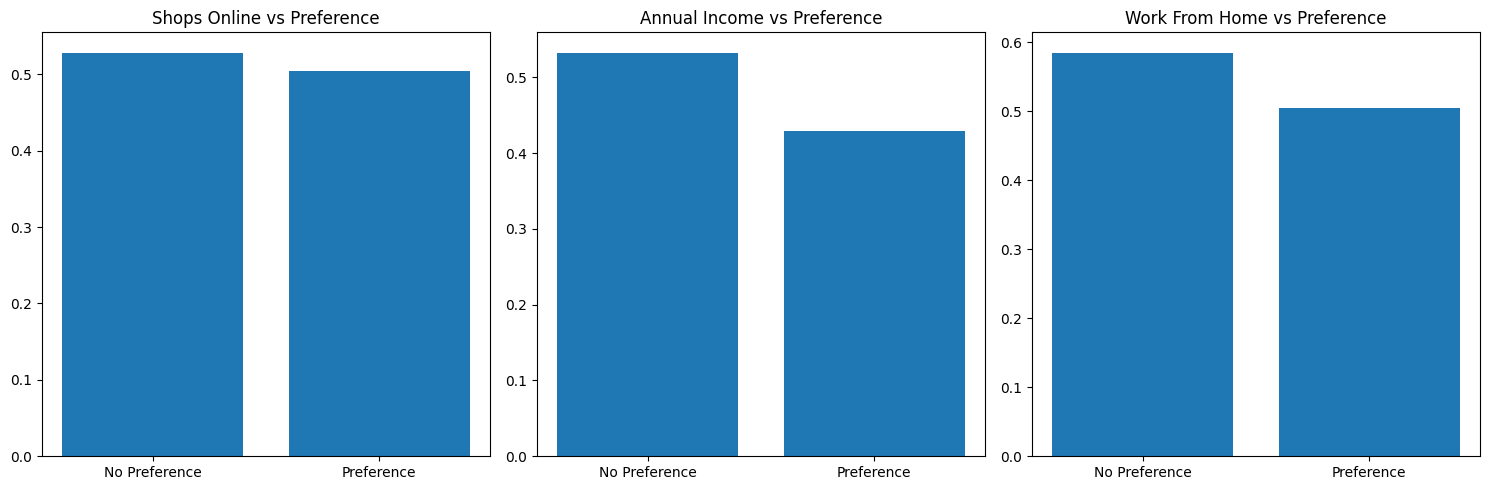

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd



df = pd.DataFrame(dine1)

# Grouping data by 'Preference' and calculating mean for binary variables
grouped = df.groupby('Preference').mean().reset_index()

# Bar chart for binary variables against Preference
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].bar(grouped['Preference'], grouped['ShopsOnline'])
axs[0].set_title('Shops Online vs Preference')
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['No Preference', 'Preference'])

axs[1].bar(grouped['Preference'], grouped['Annual Income'])
axs[1].set_title('Annual Income vs Preference')
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['No Preference', 'Preference'])

axs[2].bar(grouped['Preference'], grouped['WorkFromHome'])
axs[2].set_title('Work From Home vs Preference')
axs[2].set_xticks([0, 1])
axs[2].set_xticklabels(['No Preference', 'Preference'])

plt.tight_layout()
plt.show()


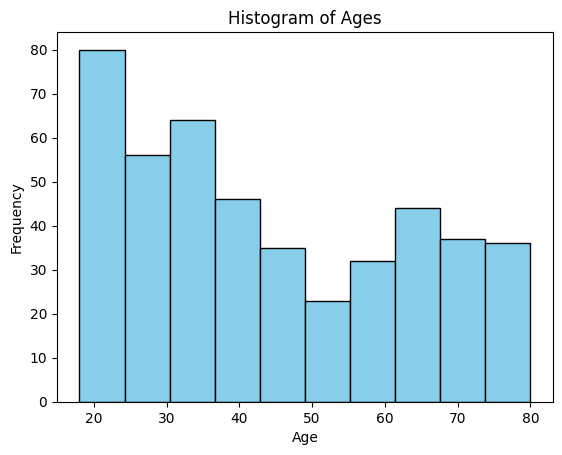

In [ ]:
import matplotlib.pyplot as plt

plt.hist(dine1['Age'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Histogram of Ages')
plt.show()


In [ ]:
rewards1.head()

,Date,LoyaltyAccepted,StoreID,Customer ID,CustomerMaritalStatus,CustomerGender,Age,Annual Income,Amount Spent ($),Shops Online or Not
0,2021-05-29,0,1,1,Single,Other,33,76.0,41,1
1,2020-08-19,1,2,2,Prefer not to answer,Female,48,102.0,103,0
2,2019-10-07,1,3,3,Prefer not to answer,Prefer not to answer,50,87.0,174,0
3,2020-10-29,1,4,4,Prefer not to answer,Prefer not to answer,37,150.0,32,1
4,2020-06-11,1,5,5,Married,Prefer not to answer,67,141.0,148,0


In [ ]:
rewards1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 925 entries, 0 to 932
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   925 non-null    datetime64[ns]
 1   LoyaltyAccepted        925 non-null    int64         
 2   StoreID                925 non-null    int64         
 3   Customer ID            925 non-null    int64         
 4   CustomerMaritalStatus  925 non-null    object        
 5   CustomerGender         924 non-null    object        
 6   Age                    925 non-null    int64         
 7   Annual Income          924 non-null    float64       
 8   Amount Spent ($)       925 non-null    int64         
 9   Shops Online or Not    925 non-null    uint8         
dtypes: datetime64[ns](1), float64(1), int64(5), object(2), uint8(1)
memory usage: 73.2+ KB


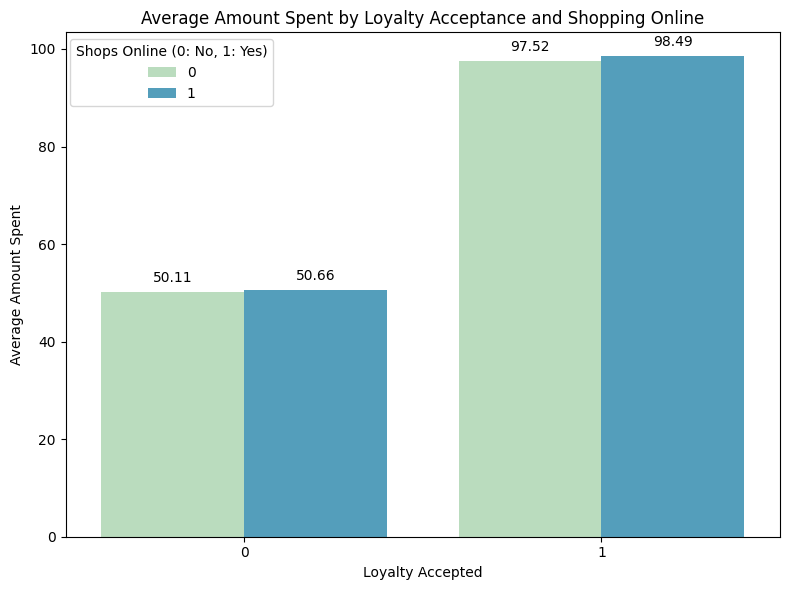

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating the average amount spent by LoyaltyAccepted and Shops_Online_or_Not
avg_amount_spent = rewards1.groupby(['LoyaltyAccepted', 'Shops Online or Not'])['Amount Spent ($)'].mean().reset_index()

# Creating a bar plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='LoyaltyAccepted', y='Amount Spent ($)', hue='Shops Online or Not', data=avg_amount_spent, palette='GnBu')

# Adding values on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')

plt.xlabel('Loyalty Accepted')
plt.ylabel('Average Amount Spent')
plt.title('Average Amount Spent by Loyalty Acceptance and Shopping Online')
plt.legend(title='Shops Online (0: No, 1: Yes)', loc='upper right', bbox_to_anchor=(.3, 1.0))
plt.tight_layout()
plt.show()


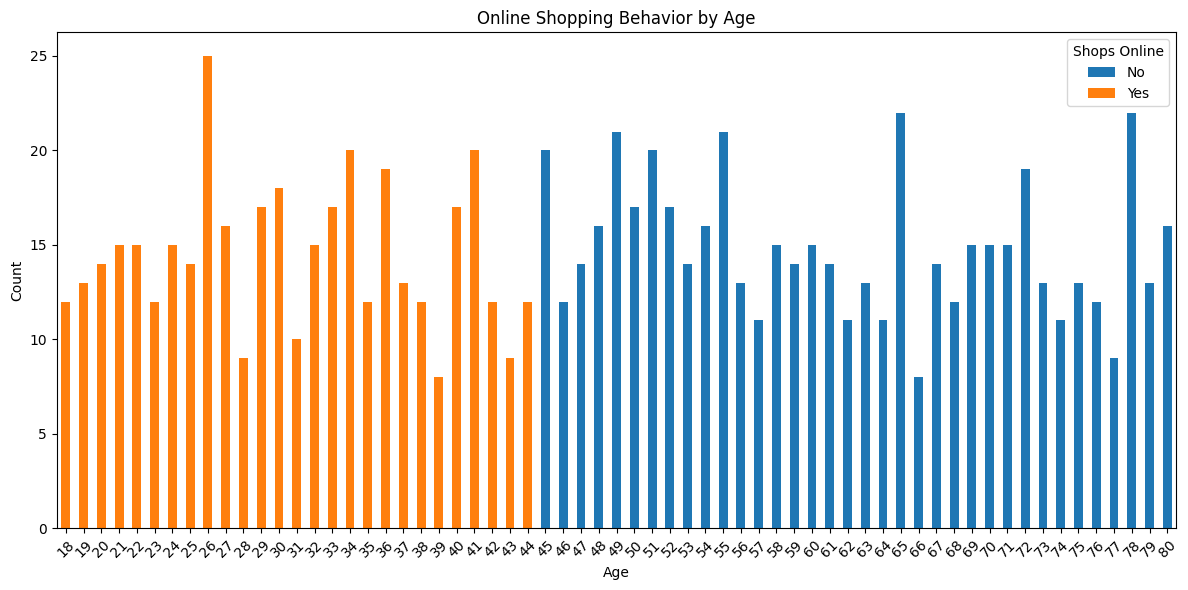

In [ ]:
import matplotlib.pyplot as plt

# Group by Age and Shops_Online_or_Not, then count occurrences
age_online_count = rewards1.groupby(['Age', 'Shops Online or Not']).size().unstack()

# Plotting the count of online shoppers by age with a transparent background
plt.figure(figsize=(12, 6))
age_online_count.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Online Shopping Behavior by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Shops Online', labels=['No', 'Yes'])  # Legend for online shopping (No/Yes)
plt.tight_layout()

# Save the plot with transparent background
plt.savefig('online_shopping_behavior.png', transparent=True)  # Save with transparent background
plt.show()

# **Hypothesis Test on Proportions**

###DineInTakeOut

In [ ]:
# Q1: How does work from home influence preference for dine in and take out

from statsmodels.stats.proportion import proportions_ztest

## Work from home
wfh = dine1[dine1['WorkFromHome'] == 1]['Preference']
not_wfh = dine1[dine1['WorkFromHome'] == 0]['Preference']

# Number of people who prefer to dine-in
dineIn = [wfh.sum(), not_wfh.sum()]

# Number of observations in each group
nobs = [wfh.count(), not_wfh.count()]

# Performing two-proportion z-test
z_stat, p_value = proportions_ztest(count=dineIn, nobs=nobs, alternative='two-sided')

print("Hypothesis Test on Proportions: Work from Home Influence on Dining Preferences")
print(f"P-value: {p_value:.4f}")

Hypothesis Test on Proportions: Work from Home Influence on Dining Preferences
P-value: 0.0846


In [ ]:
# Q2: How does annual income influence preference for dine in and take out?

above139 = dine1[dine1['Annual Income'] == 1]['Preference']
below139 = dine1[dine1['Annual Income'] == 0]['Preference']

# Number of people who prefer dine-in
dineIn1 = [above139.sum(), below139.sum()]

# Number of observations in each group
nobs1 = [above139.count(), below139.count()]

# Performing two-proportion z-test
z_stat_income, p_value_income = proportions_ztest(count=dineIn1, nobs=nobs1, alternative='two-sided')

print("Hypothesis Test on Proportions: Amount spent Influence on Dining Preferences")
print(f"P-value: {p_value_income:.4f}")

Hypothesis Test on Proportions: Amount spent Influence on Dining Preferences
P-value: 0.0265


# **Hypothesis Test on Means**

###Rewards Program

In [ ]:
# Q3: How does loyalty program influence amount spent?

no_loyalty = rewards1[rewards1['LoyaltyAccepted'] == 0]
yes_loyalty = rewards1[rewards1['LoyaltyAccepted'] == 1]

t_statistic, p_value_loyaltyamountspent = stats.ttest_ind(no_loyalty['Amount Spent ($)'], yes_loyalty['Amount Spent ($)'], equal_var = False)
print (f"Welch's T-Test P-Value: {p_value_loyaltyamountspent:0.4}")

Welch's T-Test P-Value: 6.235e-57


In [ ]:
# Q4: How does shops online or not influence amount spent?

no_online = rewards1[rewards1['Shops Online or Not'] == 0]
yes_online = rewards1[rewards1['Shops Online or Not'] == 1]

t_statistic, p_value_onlineamountspent = stats.ttest_ind(no_online['Amount Spent ($)'], yes_online['Amount Spent ($)'], equal_var = False)
print (f"Welch's T-Test P-Value: {p_value_onlineamountspent:0.4}")

Welch's T-Test P-Value: 0.7938


# **Regression in Experiments**

Since DineIn dataset did not have continuous response variable, we did not run the regression.

###Rewards Program

In [ ]:
rewards1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 925 entries, 0 to 932
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   925 non-null    datetime64[ns]
 1   LoyaltyAccepted        925 non-null    int64         
 2   StoreID                925 non-null    int64         
 3   Customer ID            925 non-null    int64         
 4   CustomerMaritalStatus  925 non-null    object        
 5   CustomerGender         924 non-null    object        
 6   Age                    925 non-null    int64         
 7   Annual Income          924 non-null    float64       
 8   Amount Spent ($)       925 non-null    int64         
 9   Shops Online or Not    925 non-null    uint8         
dtypes: datetime64[ns](1), float64(1), int64(5), object(2), uint8(1)
memory usage: 73.2+ KB


In [ ]:
# Q3: How does loyalty program influence amount spent?

rewards1['LoyaltyAccepted'] = rewards1['LoyaltyAccepted'].astype(int)

x3 = sm.add_constant(rewards1['LoyaltyAccepted'])
y3 = rewards1['Amount Spent ($)']
est3 = sm.OLS (y3,x3).fit()
print(est3.summary())

                            OLS Regression Results                            
Dep. Variable:       Amount Spent ($)   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                     361.1
Date:                Thu, 14 Dec 2023   Prob (F-statistic):           3.26e-68
Time:                        19:01:50   Log-Likelihood:                -4677.4
No. Observations:                 925   AIC:                             9359.
Df Residuals:                     923   BIC:                             9368.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              50.3437      1.731     

In [ ]:
rewards1.head()

,Date,LoyaltyAccepted,StoreID,Customer ID,CustomerMaritalStatus,CustomerGender,Age,Annual Income,Amount Spent ($),Shops Online or Not
0,2021-05-29,0,1,1,Single,Other,33,76.0,41,1
1,2020-08-19,1,2,2,Prefer not to answer,Female,48,102.0,103,0
2,2019-10-07,1,3,3,Prefer not to answer,Prefer not to answer,50,87.0,174,0
3,2020-10-29,1,4,4,Prefer not to answer,Prefer not to answer,37,150.0,32,1
4,2020-06-11,1,5,5,Married,Prefer not to answer,67,141.0,148,0


In [ ]:
rewards1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 925 entries, 0 to 932
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   925 non-null    datetime64[ns]
 1   LoyaltyAccepted        925 non-null    int64         
 2   StoreID                925 non-null    int64         
 3   Customer ID            925 non-null    int64         
 4   CustomerMaritalStatus  925 non-null    object        
 5   CustomerGender         924 non-null    object        
 6   Age                    925 non-null    int64         
 7   Annual Income          924 non-null    float64       
 8   Amount Spent ($)       925 non-null    int64         
 9   Shops Online or Not    925 non-null    uint8         
dtypes: datetime64[ns](1), float64(1), int64(5), object(2), uint8(1)
memory usage: 73.2+ KB


In [ ]:
import pandas as pd

# Convert to numeric with errors='coerce' to handle non-convertible values
rewards1['Annual Income'] = pd.to_numeric(rewards1['Annual Income'], errors='coerce')

# Replace infinite or non-finite values (such as 'inf', 'NaN') with NaN
rewards1['Annual Income'] = rewards1['Annual Income'].replace([np.inf, -np.inf], np.nan)

# Convert to nullable integers after handling non-finite values
rewards1['Annual Income'] = rewards1['Annual Income'].fillna(0).astype('int64')

# Convert values based on the condition
rewards1['Income_Above_105'] = rewards1['Annual Income'].apply(lambda x: 1 if x and x > 105 else 0)

rewards1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 925 entries, 0 to 932
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   925 non-null    datetime64[ns]
 1   LoyaltyAccepted        925 non-null    int64         
 2   StoreID                925 non-null    int64         
 3   Customer ID            925 non-null    int64         
 4   CustomerMaritalStatus  925 non-null    object        
 5   CustomerGender         924 non-null    object        
 6   Age                    925 non-null    int64         
 7   Annual Income          925 non-null    int64         
 8   Amount Spent ($)       925 non-null    int64         
 9   Shops Online or Not    925 non-null    uint8         
 10  Income_Above_105       925 non-null    int64         
dtypes: datetime64[ns](1), int64(7), object(2), uint8(1)
memory usage: 80.4+ KB


In [ ]:
# Convert to numeric and then to nullable integers
rewards1['Age'] = pd.to_numeric(rewards1['Age'], errors='coerce').astype('int64')

In [ ]:
covariates2 = ['Annual Income', 'Age', 'Shops Online or Not']

X6 = sm.add_constant(rewards1[['LoyaltyAccepted'] + covariates2])
y6 = rewards1['Amount Spent ($)']

est6 = sm.OLS(y6, X6).fit()
print(est6.summary())

                            OLS Regression Results                            
Dep. Variable:       Amount Spent ($)   R-squared:                       0.283
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                     90.69
Date:                Thu, 14 Dec 2023   Prob (F-statistic):           5.18e-65
Time:                        19:01:50   Log-Likelihood:                -4676.4
No. Observations:                 925   AIC:                             9363.
Df Residuals:                     920   BIC:                             9387.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  63.7181    

In [ ]:
np.mean(rewards1['Annual Income'])

105.1254054054054

In [ ]:
# Q4: How does shops online or not influence amount spent?

x4 = sm.add_constant(rewards1['Shops Online or Not'])
y4 = rewards1['Amount Spent ($)']
est4 = sm.OLS (y4,x4).fit()
print(est4.summary())

                            OLS Regression Results                            
Dep. Variable:       Amount Spent ($)   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.06850
Date:                Thu, 14 Dec 2023   Prob (F-statistic):              0.794
Time:                        19:01:50   Log-Likelihood:                -4830.0
No. Observations:                 925   AIC:                             9664.
Df Residuals:                     923   BIC:                             9674.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  72.7528    

In [ ]:
rewards1.info()
rewards1['CustomerGender'].unique()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 925 entries, 0 to 932
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   925 non-null    datetime64[ns]
 1   LoyaltyAccepted        925 non-null    int64         
 2   StoreID                925 non-null    int64         
 3   Customer ID            925 non-null    int64         
 4   CustomerMaritalStatus  925 non-null    object        
 5   CustomerGender         924 non-null    object        
 6   Age                    925 non-null    int64         
 7   Annual Income          925 non-null    int64         
 8   Amount Spent ($)       925 non-null    int64         
 9   Shops Online or Not    925 non-null    uint8         
 10  Income_Above_105       925 non-null    int64         
dtypes: datetime64[ns](1), int64(7), object(2), uint8(1)
memory usage: 80.4+ KB


array(['Other', 'Female', 'Prefer not to answer', 'Non-binary', 'Male',
       nan], dtype=object)

In [ ]:
rewards1.corr()

<ipython-input-45-65c8a207d4b1>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  rewards1.corr()


,LoyaltyAccepted,StoreID,Customer ID,Age,Annual Income,Amount Spent ($),Shops Online or Not,Income_Above_105
LoyaltyAccepted,1.000000,0.026688,0.026688,-0.025994,-0.043693,0.530299,0.000725,-0.000650
StoreID,0.026688,1.000000,1.000000,0.020978,0.027854,0.050251,-0.032907,0.037586
Customer ID,0.026688,1.000000,1.000000,0.020978,0.027854,0.050251,-0.032907,0.037586
Age,-0.025994,0.020978,0.020978,1.000000,-0.037228,-0.037915,-0.852377,-0.059397
Annual Income,-0.043693,0.027854,0.027854,-0.037228,1.000000,-0.042679,0.024642,0.864009
Amount Spent ($),0.530299,0.050251,0.050251,-0.037915,-0.042679,1.000000,0.008615,-0.013211
Shops Online or Not,0.000725,-0.032907,-0.032907,-0.852377,0.024642,0.008615,1.000000,0.042011
Income_Above_105,-0.000650,0.037586,0.037586,-0.059397,0.864009,-0.013211,0.042011,1.000000


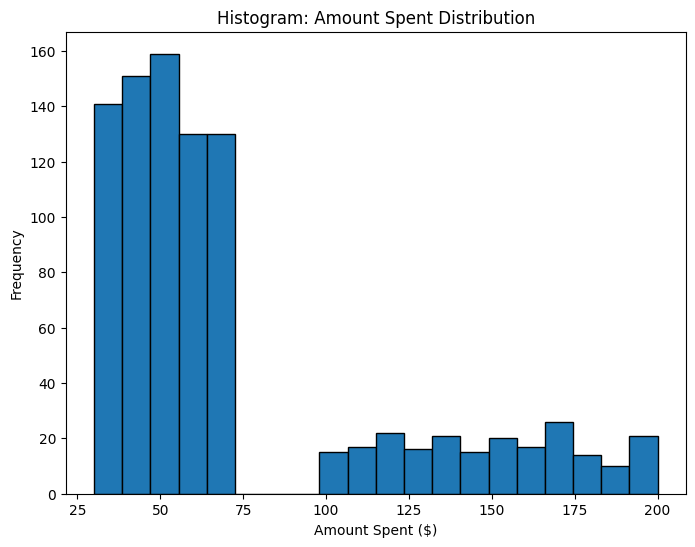

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))
plt.hist(rewards1['Amount Spent ($)'], bins=20, edgecolor='black')

plt.xlabel('Amount Spent ($)')
plt.ylabel('Frequency')
plt.title('Histogram: Amount Spent Distribution')


plt.show()



In [ ]:
rewards1.head(10 )


,Date,LoyaltyAccepted,StoreID,Customer ID,CustomerMaritalStatus,CustomerGender,Age,Annual Income,Amount Spent ($),Shops Online or Not,Income_Above_105
0,2021-05-29,0,1,1,Single,Other,33,76,41,1,0
1,2020-08-19,1,2,2,Prefer not to answer,Female,48,102,103,0,0
2,2019-10-07,1,3,3,Prefer not to answer,Prefer not to answer,50,87,174,0,0
3,2020-10-29,1,4,4,Prefer not to answer,Prefer not to answer,37,150,32,1,1
4,2020-06-11,1,5,5,Married,Prefer not to answer,67,141,148,0,1
5,2020-05-10,1,6,6,Single,Non-binary,54,116,169,0,1
6,2021-07-12,0,7,7,Prefer not to answer,Other,53,89,32,0,0
7,2019-10-15,0,8,8,With a partner,Female,36,118,41,1,1
8,2020-01-29,1,9,9,Prefer not to answer,Non-binary,78,61,46,0,0
9,2019-07-10,1,10,10,Prefer not to answer,Female,80,146,69,0,1


# **Heterogeneity and CATE**

###Rewards Program

In [ ]:
rewards1.rename(columns = {'Shops Online or Not': 'Shops_Online_or_Not', 'Annual Income': 'Annual_Income', 'Amount Spent ($)': 'Amount_Spent','Customer ID':'Customer_ID'}, inplace=True)

print(rewards1.head())

        Date  LoyaltyAccepted  StoreID  Customer_ID CustomerMaritalStatus  \
0 2021-05-29                0        1            1                Single   
1 2020-08-19                1        2            2  Prefer not to answer   
2 2019-10-07                1        3            3  Prefer not to answer   
3 2020-10-29                1        4            4  Prefer not to answer   
4 2020-06-11                1        5            5               Married   

         CustomerGender  Age  Annual_Income  Amount_Spent  \
0                 Other   33             76            41   
1                Female   48            102           103   
2  Prefer not to answer   50             87           174   
3  Prefer not to answer   37            150            32   
4  Prefer not to answer   67            141           148   

   Shops_Online_or_Not  Income_Above_105  
0                    1                 0  
1                    0                 0  
2                    0                 0 

In [ ]:
import statsmodels.api as sm
import numpy as np

rewards1['Annual_Income'] = pd.to_numeric(rewards1['Annual_Income'], errors='coerce')
rewards1['Shops_Online_or_Not'] = pd.to_numeric(rewards1['Shops_Online_or_Not'], errors='coerce')

rewards1.dropna(subset=['Annual_Income', 'Shops_Online_or_Not'], inplace=True)

mean_annual_income = rewards1['Annual_Income'].mean()

# Create a dummy variable for 'Annual_Income' based on the mean
rewards1['Annual_Income_Dummy'] = (rewards1['Annual_Income'] >= mean_annual_income).astype(int)

In [ ]:
# Create the interaction term with the dummy variable
rewards1['OnlineIncome_Dummy'] = rewards1['Annual_Income_Dummy'] * rewards1['Shops_Online_or_Not']

# Does shopping online or not influence on Amount Spent
X = sm.add_constant(rewards1[['Annual_Income_Dummy', 'Shops_Online_or_Not', 'OnlineIncome_Dummy']])
y = rewards1['Amount_Spent']

model = sm.OLS(y, X)
results = model.fit()

# Print the regression summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           Amount_Spent   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.2485
Date:                Thu, 14 Dec 2023   Prob (F-statistic):              0.862
Time:                        19:01:51   Log-Likelihood:                -4829.7
No. Observations:                 925   AIC:                             9667.
Df Residuals:                     921   BIC:                             9687.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  72.4708    

In [ ]:
coef_online = results.params['Shops_Online_or_Not']
coef_high = results.params['Annual_Income_Dummy']
coef_online_high = results.params['OnlineIncome_Dummy']

# Calculate CATE for lows (substitute coefficients into the formula)
cate_high = coef_online + coef_online_high
cate_low = coef_online
print("CATE for annual income below 105K:", cate_low)
print("CATE for annual income above 105K:", cate_high)

CATE for annual income below 105K: 3.0128927324658665
CATE for annual income above 105K: -1.2480676328502165


In [ ]:
from statsmodels.formula.api import ols
print("\n")
model = ols('Amount_Spent ~ C(Shops_Online_or_Not) + C(Annual_Income_Dummy) + C(Shops_Online_or_Not):C(Annual_Income_Dummy)', data=rewards1).fit()
sm.stats.anova_lm(model)

,df,sum_sq,mean_sq,F,PR(>F)
C(Shops_Online_or_Not),1.0,1.379356e+02,137.935596,0.068407,0.793729
C(Annual_Income_Dummy),1.0,3.430086e+02,343.008567,0.170109,0.680111
C(Shops_Online_or_Not):C(Annual_Income_Dummy),1.0,1.022199e+03,1022.199370,0.506942,0.476646
Residual,921.0,1.857107e+06,2016.403308,NaN,NaN


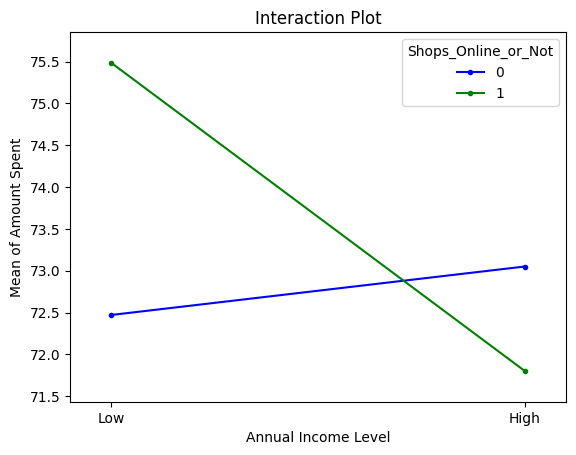

In [ ]:
from statsmodels.graphics.factorplots import interaction_plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
interaction_plot(x=rewards1['Annual_Income_Dummy'], trace=rewards1['Shops_Online_or_Not'],
                 response=rewards1['Amount_Spent'], colors=['blue', 'green'], ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Low', 'High'])
plt.title('Interaction Plot')
plt.xlabel('Annual Income Level')
plt.ylabel('Mean of Amount Spent')
plt.show()

In [ ]:
# Loyalty Program influence on Amount Spent($)

rewards1['Loyalty_Income'] = rewards1['Annual_Income_Dummy'] * rewards1['LoyaltyAccepted']

# Run the regression model with the interaction term using the dummy variable
X = sm.add_constant(rewards1[['Annual_Income_Dummy', 'LoyaltyAccepted', 'Loyalty_Income']])
y = rewards1['Amount_Spent']

model = sm.OLS(y, X)
results = model.fit()

# Print the regression summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           Amount_Spent   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                     120.7
Date:                Thu, 14 Dec 2023   Prob (F-statistic):           6.40e-66
Time:                        19:01:51   Log-Likelihood:                -4676.7
No. Observations:                 925   AIC:                             9361.
Df Residuals:                     921   BIC:                             9381.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  49.7029    

In [ ]:
# Extract coefficients
coef_treatment = results.params['LoyaltyAccepted']
coef_high = results.params['Annual_Income_Dummy']
coef_treatment_high = results.params['Loyalty_Income']

# Calculate CATE for lows (substitute coefficients into the formula)
cate_high = coef_treatment + coef_treatment_high
cate_low = coef_treatment
print("CATE for annual income below 105K:", cate_low)
print("CATE for annual income above 105K:", cate_high)

CATE for annual income below 105K: 50.14638619820033
CATE for annual income above 105K: 45.07801587885027


In [ ]:
from statsmodels.formula.api import ols
print("\n")
model = ols('Amount_Spent ~ C(LoyaltyAccepted) + C(Annual_Income_Dummy) + C(LoyaltyAccepted):C(Annual_Income_Dummy)', data=rewards1).fit()
sm.stats.anova_lm(model)

,df,sum_sq,mean_sq,F,PR(>F)
C(LoyaltyAccepted),1.0,5.226737e+05,522673.678229,360.816603,3.815095e-68
C(Annual_Income_Dummy),1.0,3.076678e+02,307.667776,0.212392,6.450079e-01
C(LoyaltyAccepted):C(Annual_Income_Dummy),1.0,1.482052e+03,1482.052339,1.023103,3.120497e-01
Residual,921.0,1.334147e+06,1448.585442,NaN,NaN


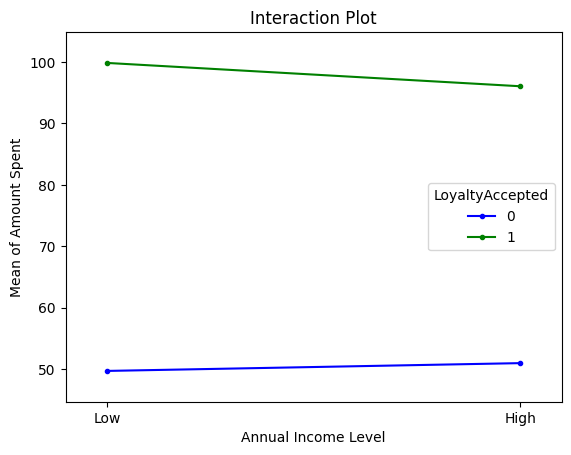

In [ ]:
from statsmodels.graphics.factorplots import interaction_plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
interaction_plot(trace=rewards1['LoyaltyAccepted'], x=rewards1['Annual_Income_Dummy'],
                       response=rewards1['Amount_Spent'], colors=['blue', 'green'], ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Low', 'High'])
plt.title('Interaction Plot')
plt.xlabel('Annual Income Level')
plt.ylabel('Mean of Amount Spent')
plt.show()

# **DoWhy**

###Rewards Program

In [ ]:
!pip install dowhy
import dowhy
from dowhy import CausalModel
import warnings
warnings.filterwarnings('ignore')

rewards1['LoyaltyAccepted'] =  rewards1['LoyaltyAccepted'].replace({1: True, 0: False})
rewards1['Shops_Online_or_Not'] =  rewards1['Shops_Online_or_Not'].replace({1: True, 0: False})

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.7/377.7 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 kB 15.8 MB/s eta 0:00:00


In [ ]:
!apt-get install graphviz libgraphviz-dev pkg-config
!pip install pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pkg-config is already the newest version (0.29.2-1ubuntu3).
graphviz is already the newest version (2.42.2-6).
The following additional packages will be installed:
  libgail-common libgail18 libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libgail-common libgail18 libgraphviz-dev libgtk2.0-0 libgtk2.0-bin libgtk2.0-common
  libgvc6-plugins-gtk librsvg2-common libxdot4
0 upgraded, 9 newly installed, 0 to remove and 24 not upgraded.
Need to get 2,433 kB of archives.
After this operation, 7,694 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libgtk2.0-common all 2.24.33-2ubuntu2 [125 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libgtk2.0-0 amd64 2.24.33-2ubuntu2 [2,037 kB]
Get:3 http://archive.ubuntu.com/ubuntu jamm

In [ ]:
causal_graph = """
digraph {
    CustomerMaritalStatus;
    Age;
    Shops_Online_or_Not;
    Annual_Income;
    Amount_Spent;
    LoyaltyAccepted;
    CustomerGender;
    Age -> CustomerMaritalStatus;
    Age -> Annual_Income;
    Shops_Online_or_Not -> LoyaltyAccepted;
    CustomerMaritalStatus -> Shops_Online_or_Not;
    CustomerGender -> Shops_Online_or_Not;
    Annual_Income -> LoyaltyAccepted;
    Age -> Amount_Spent;
    CustomerMaritalStatus -> Amount_Spent;
    Shops_Online_or_Not -> Amount_Spent;
    Annual_Income -> Amount_Spent;
    LoyaltyAccepted -> Amount_Spent;

}
"""

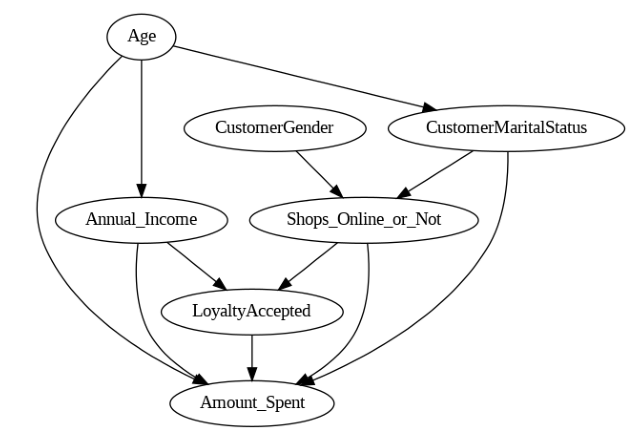

In [ ]:
# Q3: How does acceptance of loyalty program influence amount spent

from dowhy import CausalModel

# Build the model in DoWhy
model = CausalModel(
    data=rewards1,
    graph=causal_graph.replace("\n", " "),
    treatment='LoyaltyAccepted',
    outcome='Amount_Spent')
model.view_model()


estimands = model.identify_effect()

In [ ]:
# Backdoor Linear Regression

causal_estimate_reg = model.estimate_effect(estimands,
                                            method_name="backdoor.linear_regression",
                                            test_significance=True)

placebo_refute_blr = model.refute_estimate(estimands, causal_estimate_reg,
                                           method_name="placebo_treatment_refuter", num_simulations=20)

subset_refute_blr = model.refute_estimate(estimands,causal_estimate_reg,
                                            method_name = "data_subset_refuter", num_simulations=20)
print('\n')
print("BACKDOOR LINEAR REGRESSION RESULTS", '\n')
print("Results with placebo treatment refuter:")
print(placebo_refute_blr)

print("Results with data subset refuter:")
print(subset_refute_blr)

             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.
             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.




BACKDOOR LINEAR REGRESSION RESULTS 

Results with placebo treatment refuter:
Refute: Use a Placebo Treatment
Estimated effect:47.510391352167645
New effect:-0.5998953427754387
p value:0.41757188223812514

Results with data subset refuter:
Refute: Use a subset of data
Estimated effect:47.510391352167645
New effect:47.31024981439076
p value:0.4086758897443703



In [ ]:
# Backdoor Propensity Score Weighting

causal_estimate_ipw = model.estimate_effect(estimands,
                                            method_name="backdoor.propensity_score_weighting",
                                            method_params={"weighting_scheme":"ips_weight"},
                                            test_significance=True)

placebo_refute_bpsw = model.refute_estimate(estimands,causal_estimate_ipw,
                                              method_name = "placebo_treatment_refuter", num_simulations=20)

subset_refute_bpsw = model.refute_estimate(estimands,causal_estimate_ipw,
                                              method_name = "data_subset_refuter", num_simulations=20)

print('\n')
print("BACKDOOR PROPENSITY SCORE WEIGHTING RESULTS",'\n')
print("Results with placebo treatment refuter:")
print(placebo_refute_bpsw)

print("Results with data subset refuter:")
print(subset_refute_bpsw)

             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.
             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.




BACKDOOR PROPENSITY SCORE WEIGHTING RESULTS 

Results with placebo treatment refuter:
Refute: Use a Placebo Treatment
Estimated effect:47.50177410740049
New effect:0.1920678605651723
p value:0.47542918719500743

Results with data subset refuter:
Refute: Use a subset of data
Estimated effect:47.50177410740049
New effect:47.4357072746272
p value:0.4717763592059506



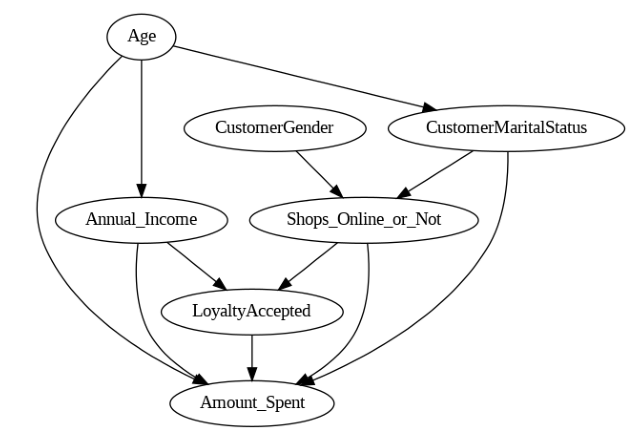

In [ ]:
# Q4: How does acceptance of shop online or not influence amount spent

# Build the model in DoWhy
model2 = CausalModel(
    data=rewards1,
    graph=causal_graph.replace("\n", " "),
    treatment='Shops_Online_or_Not',
    outcome='Amount_Spent')
model2.view_model()

estimands2 = model2.identify_effect()

In [ ]:
# Backdoor Linear Regression

causal_estimate_reg2 = model2.estimate_effect(estimands2,
                                            method_name="backdoor.linear_regression",
                                            test_significance=True)

placebo_refute_blr2 = model2.refute_estimate(estimands2, causal_estimate_reg2,
                                           method_name="placebo_treatment_refuter", num_simulations=20)

subset_refute_blr2 = model2.refute_estimate(estimands2,causal_estimate_reg2,
                                            method_name = "data_subset_refuter", num_simulations=20)

print('\n')
print("BACKDOOR LINEAR REGRESSION RESULTS",'\n')
print("Results with placebo treatment refuter:")
print(placebo_refute_blr2)

print("Results with data subset refuter:")
print(subset_refute_blr2)

             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.
             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.




BACKDOOR LINEAR REGRESSION RESULTS 

Results with placebo treatment refuter:
Refute: Use a Placebo Treatment
Estimated effect:1.0562468801146707
New effect:-0.21043024063375385
p value:0.47862079398794866

Results with data subset refuter:
Refute: Use a subset of data
Estimated effect:1.0562468801146707
New effect:0.7375461899547702
p value:0.4082968389727204



In [ ]:
# Backdoor Propensity Score Weighting

causal_estimate_ipw2 = model2.estimate_effect(estimands2,
                                            method_name="backdoor.propensity_score_weighting",
                                            method_params={"weighting_scheme":"ips_weight"},
                                            test_significance=True)

placebo_refute_bpsw2 = model2.refute_estimate(estimands2,causal_estimate_ipw2,
                                              method_name = "placebo_treatment_refuter", num_simulations=20)

subset_refute_bpsw2 = model2.refute_estimate(estimands2,causal_estimate_ipw2,
                                              method_name = "data_subset_refuter", num_simulations=20)

print('\n')
print("BACKDOOR PROPENSITY SCORE WEIGHTING RESULTS",'\n')
print("Results with placebo treatment refuter:")
print(placebo_refute_bpsw2)

print("Results with data subset refuter:")
print(subset_refute_bpsw2)

             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.
             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.




BACKDOOR PROPENSITY SCORE WEIGHTING RESULTS 

Results with placebo treatment refuter:
Refute: Use a Placebo Treatment
Estimated effect:0.5623558694519915
New effect:-1.003661810371804
p value:0.36631002934302415

Results with data subset refuter:
Refute: Use a subset of data
Estimated effect:0.5623558694519915
New effect:0.47680325752300445
p value:0.48108711583846264

